In [1]:
import omero_analysis_notebook as oan
ctx = oan.configure(r'''{"schema": "nl.bioimaging.omero-analysis-notebook.v1", "inputs": [{"id": "measurements", "kind": "query", "path": "input/measurements.duckdb", "formats": ["duckdb"], "required": true}], "results": {"path": "results"}, "parameters": [], "requirements": ["pandas", "matplotlib"]}''')
ctx.display_parameters()


 run_id plate_row plate_column  label_set_index  timepoint  cell_count  images_measured         well
      1   unknown      unknown                1          0           3                1 Well unknown


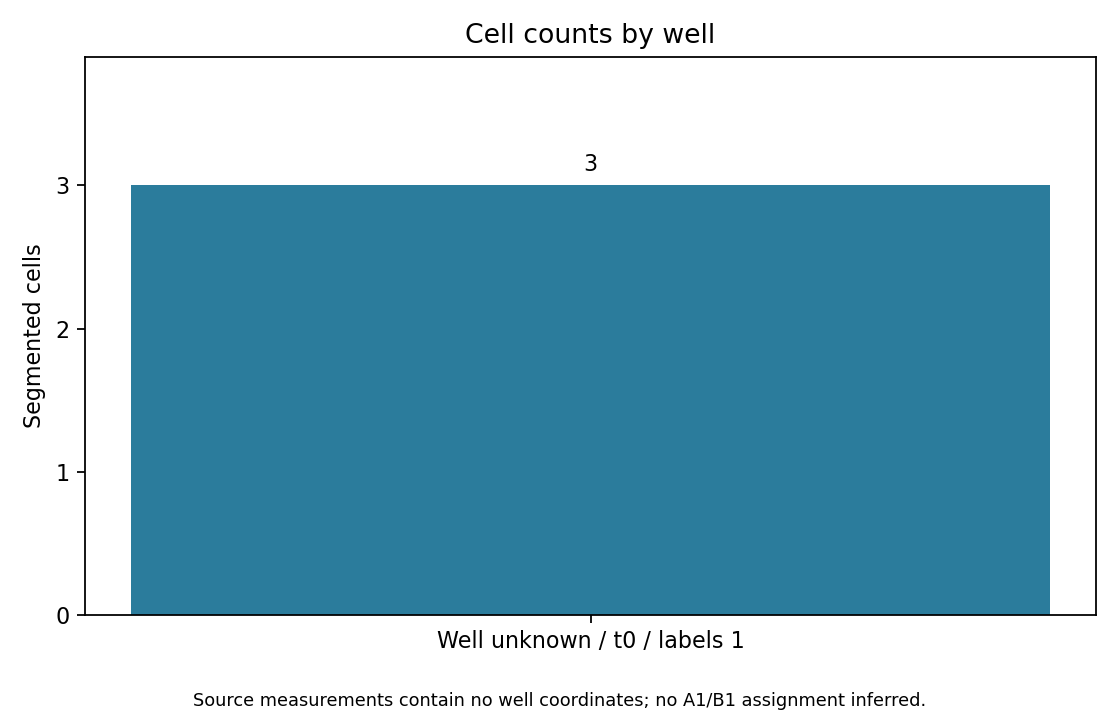

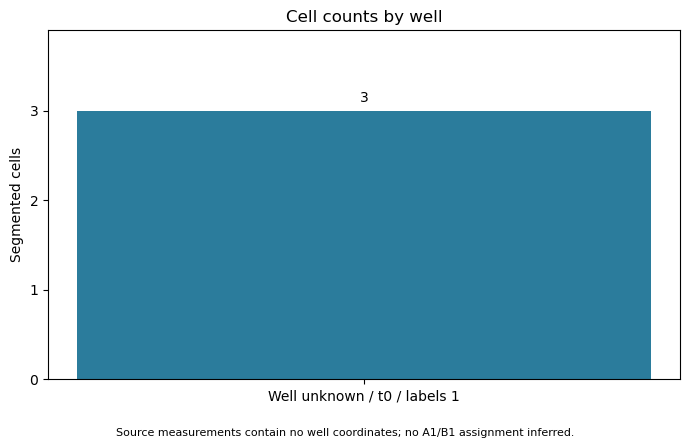

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
counts = await ctx.query("measurements", "SELECT i.run_id, COALESCE(i.plate_row, 'unknown') AS plate_row,\n COALESCE(i.plate_column, 'unknown') AS plate_column,\n l.label_set_index, o.timepoint, COUNT(*) AS cell_count,\n COUNT(DISTINCT i.image_id) AS images_measured\nFROM objects o JOIN images i ON i.image_id=o.image_id\nJOIN label_sets l ON l.label_set_id=o.label_set_id\nWHERE l.object_type='cells' AND NOT o.is_point\nGROUP BY i.run_id, i.plate_row, i.plate_column, l.label_set_index, o.timepoint\nORDER BY i.run_id, i.plate_row, i.plate_column, l.label_set_index, o.timepoint")
counts["well"] = counts.apply(lambda r: "Well unknown" if "unknown" in (r.plate_row, r.plate_column) else str(r.plate_row) + str(r.plate_column), axis=1)
counts.to_csv(ctx.results / "cells-per-well.csv", index=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = [f"{r.well} / t{r.timepoint} / labels {r.label_set_index}" for r in counts.itertuples()]
bars = ax.bar(labels, counts["cell_count"], color="#2b7c9c")
ax.bar_label(bars, padding=4)
ax.set(title="Cell counts by well", ylabel="Segmented cells")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(0, max(counts["cell_count"].max() * 1.3, 1))
if (counts["well"] == "Well unknown").any():
    fig.text(0.5, 0.02, "Source measurements contain no well coordinates; no A1/B1 assignment inferred.", ha="center", fontsize=8)
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(ctx.results / "cells-per-well.png", dpi=160)
fig.savefig(ctx.results / "cells-per-well.svg")
plt.show()
print(counts.to_string(index=False))
